# Runtime Exps

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm, trange

from emc.estimator.EMC import EMCLin as EMC
from emc.generator.markov import MarkovianSwitchingSystem
from emc.utils.plot import get_mpl_conf_path, set_size

In [2]:
%load_ext autoreload
%autoreload 2

## Generate Data

In [3]:
alphabet_cardinality = 4
mode_process_order = 1
subprocess_order = 1
number_of_subprocesses = 3
number_of_regimes = 8
regime_length_bounds = [500,501]
number_of_runs = 100

runs = []
for run_count in tqdm(range(number_of_runs), desc="Runs"):

    # generate MSS, mode and symbol sequences
    mss_ins = MarkovianSwitchingSystem(
        alphabet_cardinality=alphabet_cardinality,
        mode_process_order=mode_process_order,
        subprocess_order=subprocess_order,
        number_of_subprocesses=number_of_subprocesses,
        rng_or_seed=run_count
    )
    mss_ins.generate_subprocess_sequence(
        number_of_regimes=number_of_regimes,
        avoid_loops=True
    )
    symbol_sequence = mss_ins.generate_symbol_sequence(
        regime_length_bounds=regime_length_bounds
    )

    run_params = {
        "run_count": run_count,
        "subprocess_sequence": mss_ins.subprocess_sequence,
        "regime_lengths": mss_ins.regime_lengths,
        "change_points": np.cumsum(mss_ins.regime_lengths),
        "subprocesses": mss_ins.subprocesses,
        "subprocess_sequence_full": np.repeat(mss_ins.subprocess_sequence, mss_ins.regime_lengths),
        "symbol_sequence": symbol_sequence
    }

    runs.append(run_params)

Runs:   0%|          | 0/100 [00:00<?, ?it/s]

## Runtime Tests

### Markov Order (k) vs Time

In [4]:
res_kt = []
for run in tqdm(runs, desc="Runs", leave=True):
    for k in trange(1, 51, desc="Orders", leave=False):
        obs_seq = run["symbol_sequence"]
        emc_ins = EMC(
            alpha=4,
            order=k,
            lambda_=[0.92, 0.95],
            beta=0,
            delta=[0.2, 0.2],
            eta=[0.3, 0.3],
            tau=20,
            live_memory=True
        )
        tic = time.time()
        emc_ins.process_sequence(obs_seq, progress=False)
        toc = time.time()
        res_kt.append({"run": run["run_count"], "order": k, "time": (toc - tic)/len(obs_seq)})
res_kt_df = pd.DataFrame(res_kt)

Runs:   0%|          | 0/100 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

...

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

Orders:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
res_kt_df_path = "res_kt_df.csv"
res_kt_df.to_csv(res_kt_df_path, index=False)

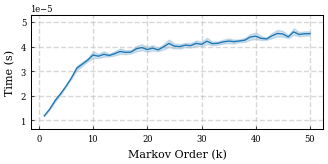

In [ ]:
data = pd.read_csv(res_kt_df_path)
data = data.loc[data["order"] <= 50]

plt.style.use("default")
plt.style.use(get_mpl_conf_path("pub"))
figsize = set_size(**{"width":"generic_paper", "aspect_ratio":2, "fraction":0.5})

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(data=data, x="order", y="time", ax=ax)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_xlabel("Markov Order (k)")
ax.set_ylabel("Time (s)")
ax.grid(linewidth=1, linestyle='--', alpha=0.5)
ax.margins(x=0.05, y=0.15)

fig_path = os.path.join("emc_kt.pdf")
fig.savefig(fig_path, bbox_inches="tight")

plt.show()

### Number of States (m) vs Time

In [7]:
res_mt = []
for run in tqdm(runs, desc="Runs", leave=True):
    for m in trange(4, 51, desc="Number of States", leave=False):
        obs_seq = run["symbol_sequence"]
        emc_ins = EMC(
            alpha=m,
            order=1,
            lambda_=[0.92, 0.95],
            beta=0,
            delta=[0.2, 0.2],
            eta=[0.3, 0.3],
            tau=20,
            live_memory=True
        )
        tic = time.time()
        emc_ins.process_sequence(obs_seq, progress=False)
        toc = time.time()
        res_mt.append({"run": run["run_count"], "Number of States": m, "time": (toc - tic)/len(obs_seq)})
res_mt_df = pd.DataFrame(res_mt)

Runs:   0%|          | 0/100 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

...

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

Number of States:   0%|          | 0/47 [00:00<?, ?it/s]

In [24]:
res_mt_df_path = "res_mt_df.csv"
res_mt_df.to_csv(res_mt_df_path, index=False)

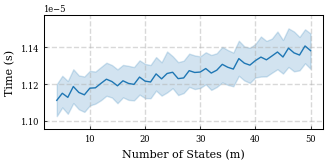

In [25]:
data = pd.read_csv(res_mt_df_path)
data = data.loc[data["Number of States"] <= 50]

plt.style.use("default")
plt.style.use(get_mpl_conf_path("pub"))
figsize = set_size(**{"width":"generic_paper", "aspect_ratio":2, "fraction":0.5})

fig, ax = plt.subplots(figsize=figsize)
sns.lineplot(data=data, x="Number of States", y="time", ax=ax)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_xlabel("Number of States (m)")
ax.set_ylabel("Time (s)")
ax.grid(linewidth=1, linestyle='--', alpha=0.5)
ax.margins(x=0.05, y=0.15)

fig_path = os.path.join("emc_mt.pdf")
fig.savefig(fig_path, bbox_inches="tight")

plt.show()